<div align="center">
    
<h2>PROJECT MODULE</h2>
<h4>Beyond Accuracy: Evaluating the stability of SHAP explanations Across Machine Learning Models for PISA 2022 Mathematics in Switzerland</h4>

</div>

<br>

**Author:** Lucas Pannatier  
**Institution:** University of London (Birkbeck College), Msc in Computer Science  
**Date:** 2026


<br>
<br>



##### **I. BUILD AND LOAD THE DATASET**

For this project, a Swiss PISA 2022 dataset reduced to the 20 features discussed in the project report has been built from the official PISA 2022 database (https://survey.oecd.org/index.php?r=survey/index&sid=197663&lang=en):

- the dataset resulting from the school questionnaire: CY08MSP_SCH_QQQ.sav (18.53 MB) 
- the dataset based on the student questionnaire: CY08MSP_STU_QQQ.sav (1.97 GB)

Code has been developed to build the Swiss reduced PISA 2022 dataset from scratch. If the user wants to do it this way, it requires manual download of the official database (a direct link is also available here: https://zenodo.org/records/13382904).

Otherwise, the Swiss reduced PISA 2022 dataset is already available in the dataset folder for the purpose of this study.


In [1]:
import os
import sys
import pandas as pd
from pathlib import Path

if Path.cwd().name == "notebook":
    os.chdir(Path.cwd().parent)

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataset_building import reduced_swiss_dataset

print("Working directory:", os.getcwd())

df_raw = "dataset/swiss_reduced_dataset.csv"

if not os.path.exists(df_raw):
    # Build the reduced Swiss dataset from PISA 2022 dataset
    # Requires manual download of the original PISA files
    df_raw = reduced_swiss_dataset()
else:
    df_raw = pd.read_csv(df_raw)

Working directory: /Users/lucaspannatier/Google Drive/UNIVERSITY OF LONDON/Master in Computer Science/Project/Project and code/PROJECT_CODE


##### **II. PREPROCESSING PROCESS**

This preprocessing pipeline performs the following steps:

1. prepares the raw dataset before splitting by removing variables and rows exceeding the missing value threshold, creating derived features (such as `MMINS` and `MEAN_ESCS`), capping extreme outliers, and mapping ordinal variables to numerical values.

2. splits the dataset into a training (70%) and a test (30%) set.

3. filters variables based on the training data only, imputes missing values, and one-hot encodes nominal variables for both the X_train and X_test datasets.


In [2]:
from src.config import MISSING_VALUES_THRESHOLD
from src.dataset_cleaning_and_preprocessing import run_preprocessing_pipeline


(X_train_imputed, 
 X_test_imputed, 
 X_train, X_test, 
 y_train, y_test, 
 df_raw_with_correct_features, 
 df_preprocessed, 
 numeric_imputed_feature_names, 
 all_imputed_feature_names, 
 removed_missing_columns) = run_preprocessing_pipeline(df_raw, MISSING_VALUES_THRESHOLD)

##### **III. GLOBAL EXPLORATORY DATA ANALYSIS**

This step saves and displays only descriptive statistics about the whole dataset, before cleaning and imputing, in the form of plots and tables. Performing the exploratory data analysis at this stage helps avoid data leakage.


GLOBAL DATA EXPLORATORY ANALYSIS (BEFORE CLEANING).txt saved to outputs/tables/GLOBAL DATA EXPLORATORY ANALYSIS (BEFORE CLEANING).txt
GLOBAL DATA EXPLORATORY ANALYSIS (CLEANED WHOLE DATASET).txt saved to outputs/tables/GLOBAL DATA EXPLORATORY ANALYSIS (CLEANED WHOLE DATASET).txt
Columns removed from training-set missingness: None
MISSING VALUES REPORT (BEFORE CLEANING).txt saved to outputs/tables/MISSING VALUES REPORT (BEFORE CLEANING).txt
15 histograms saved to outputs/plots/univariate_plots/
15 violin plots saved to outputs/plots/univariate_plots/violin_plots/
5 bar plots saved to outputs/plots/univariate_plots/barplots/
Histograms - All Numeric Features (BEFORE CLEANING AND IMPUTATION).png saved to outputs/plots/univariate_plots/histograms/
Violin Plots - All Numeric Features (BEFORE CLEANING AND IMPUTATION).png saved to outputs/plots/univariate_plots/violin_plots/
Bar Plots - All Categorical Features (BEFORE CLEANING AND IMPUTATION).png saved to outputs/plots/univariate_plots/barpl

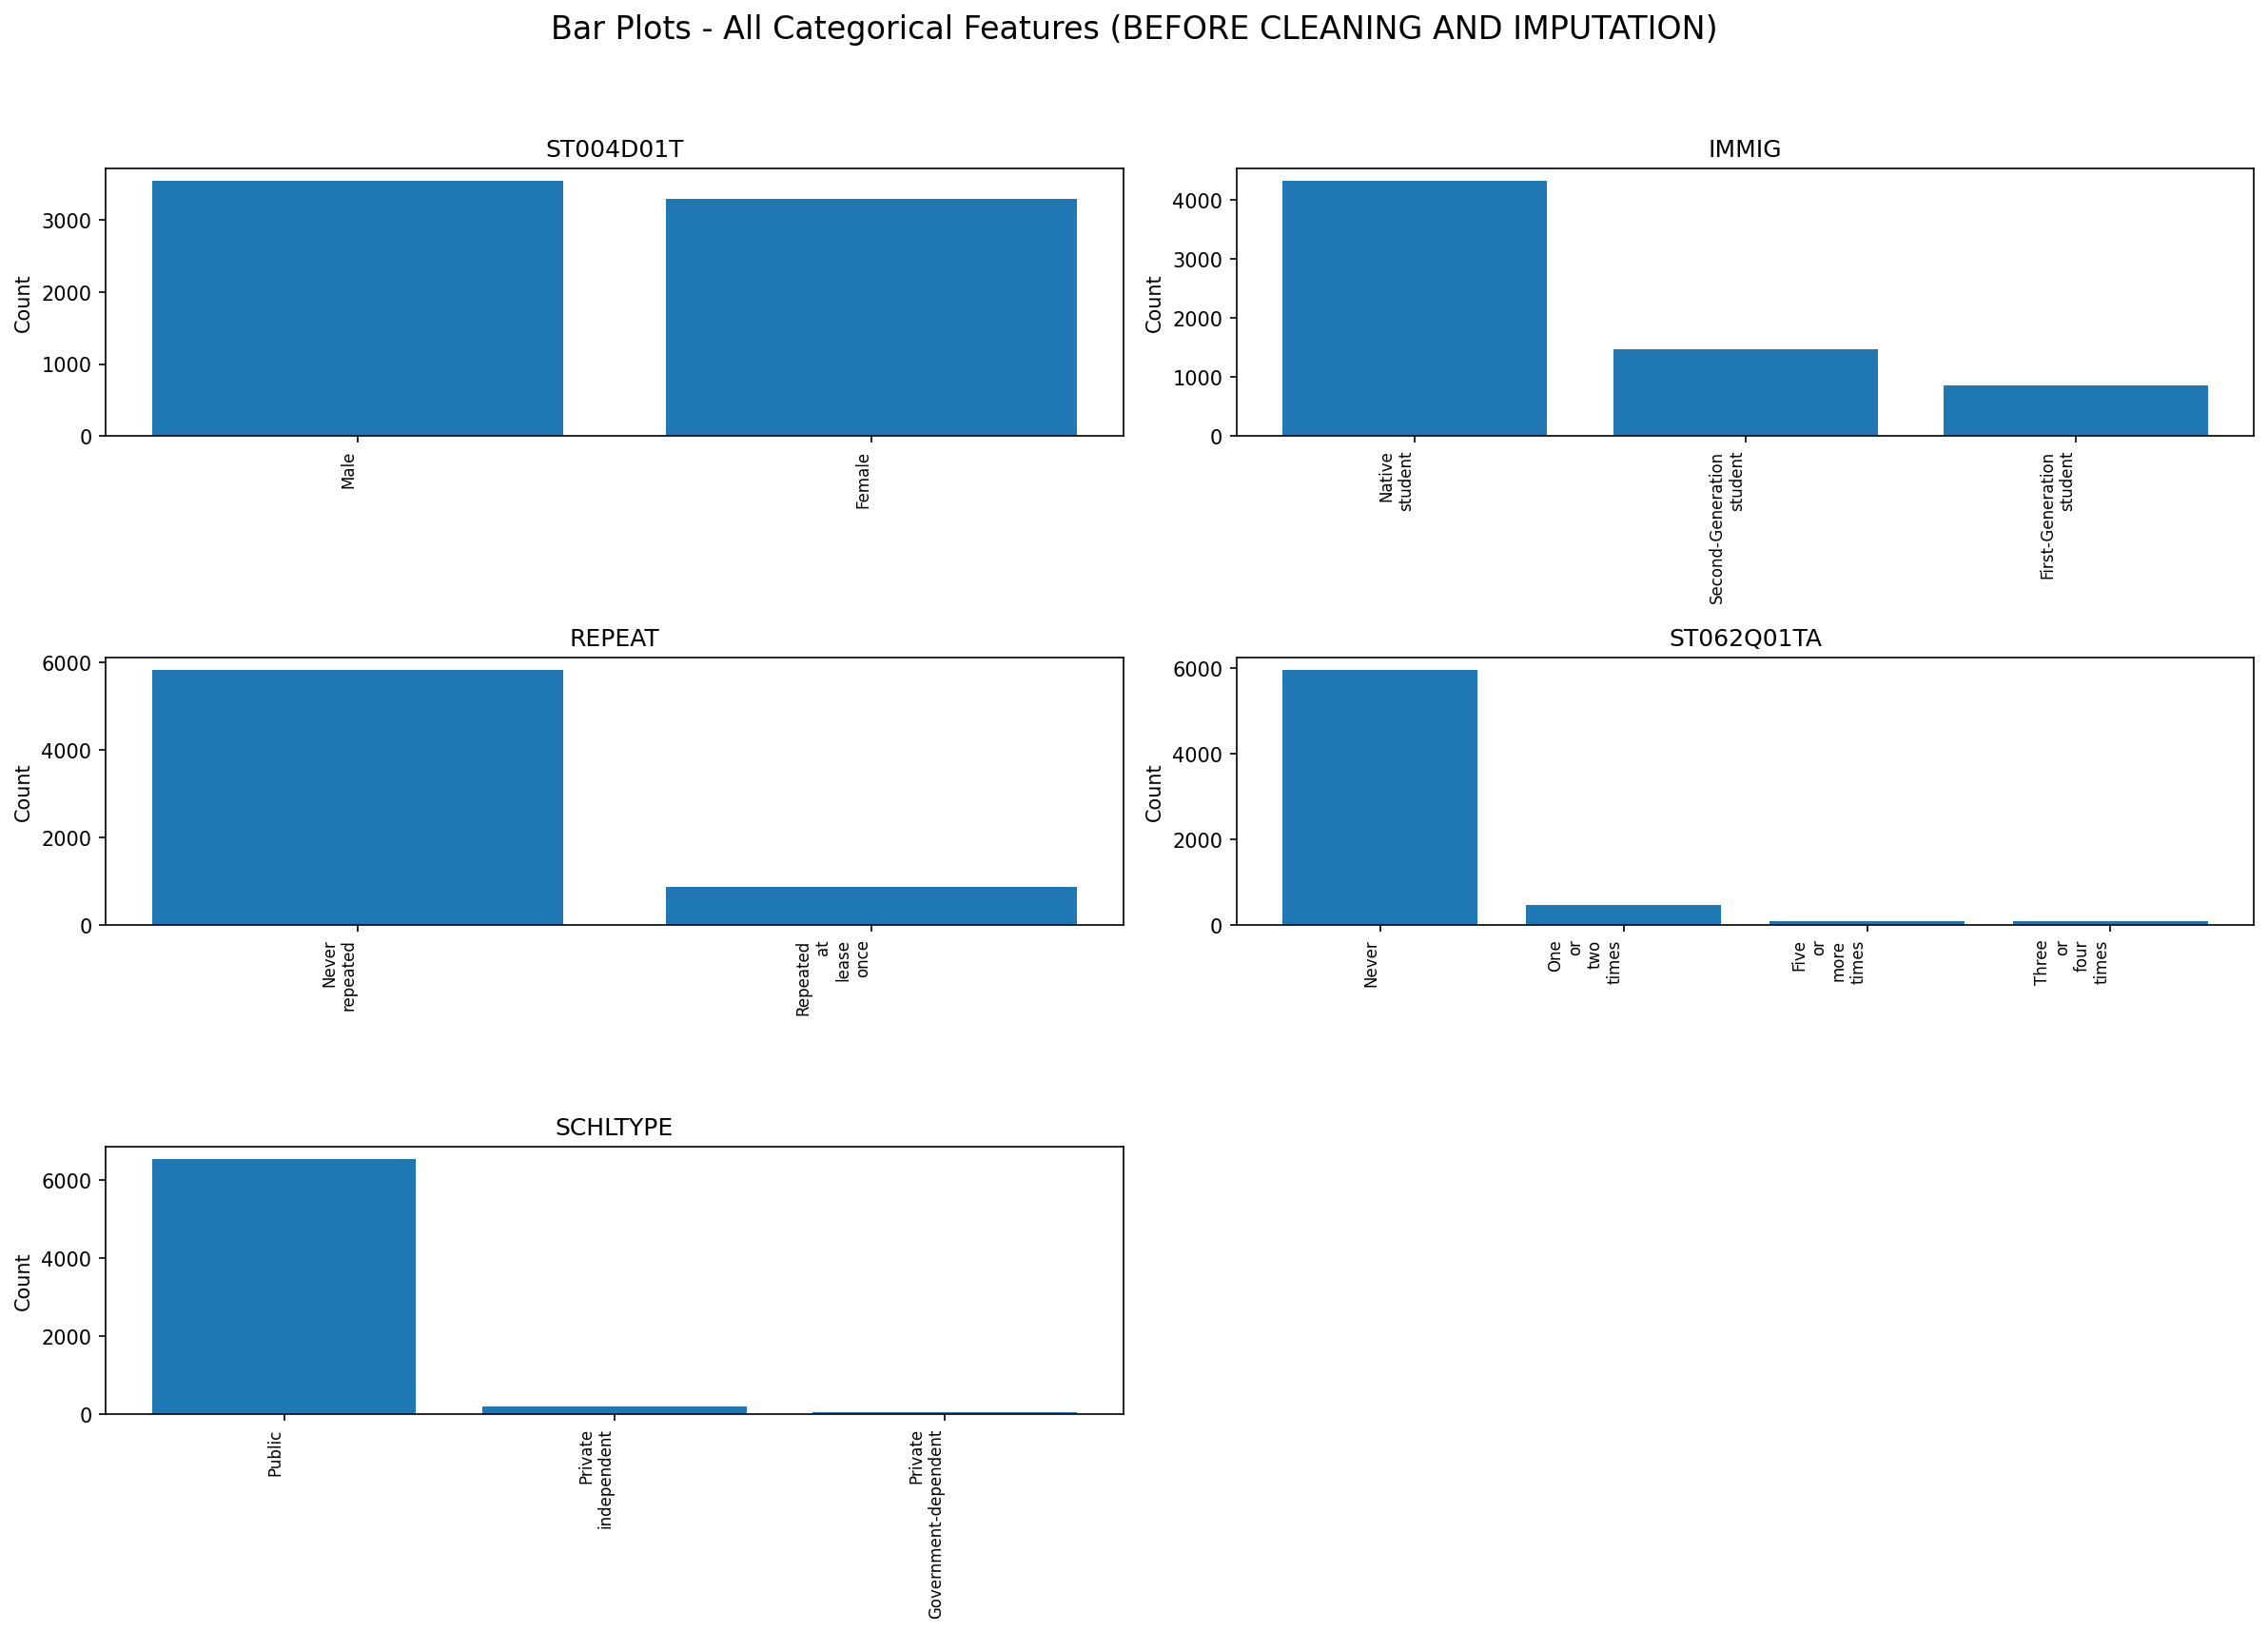


 COMBINED HISTOGRAMS FOR ALL NUMERIC FEATURES:


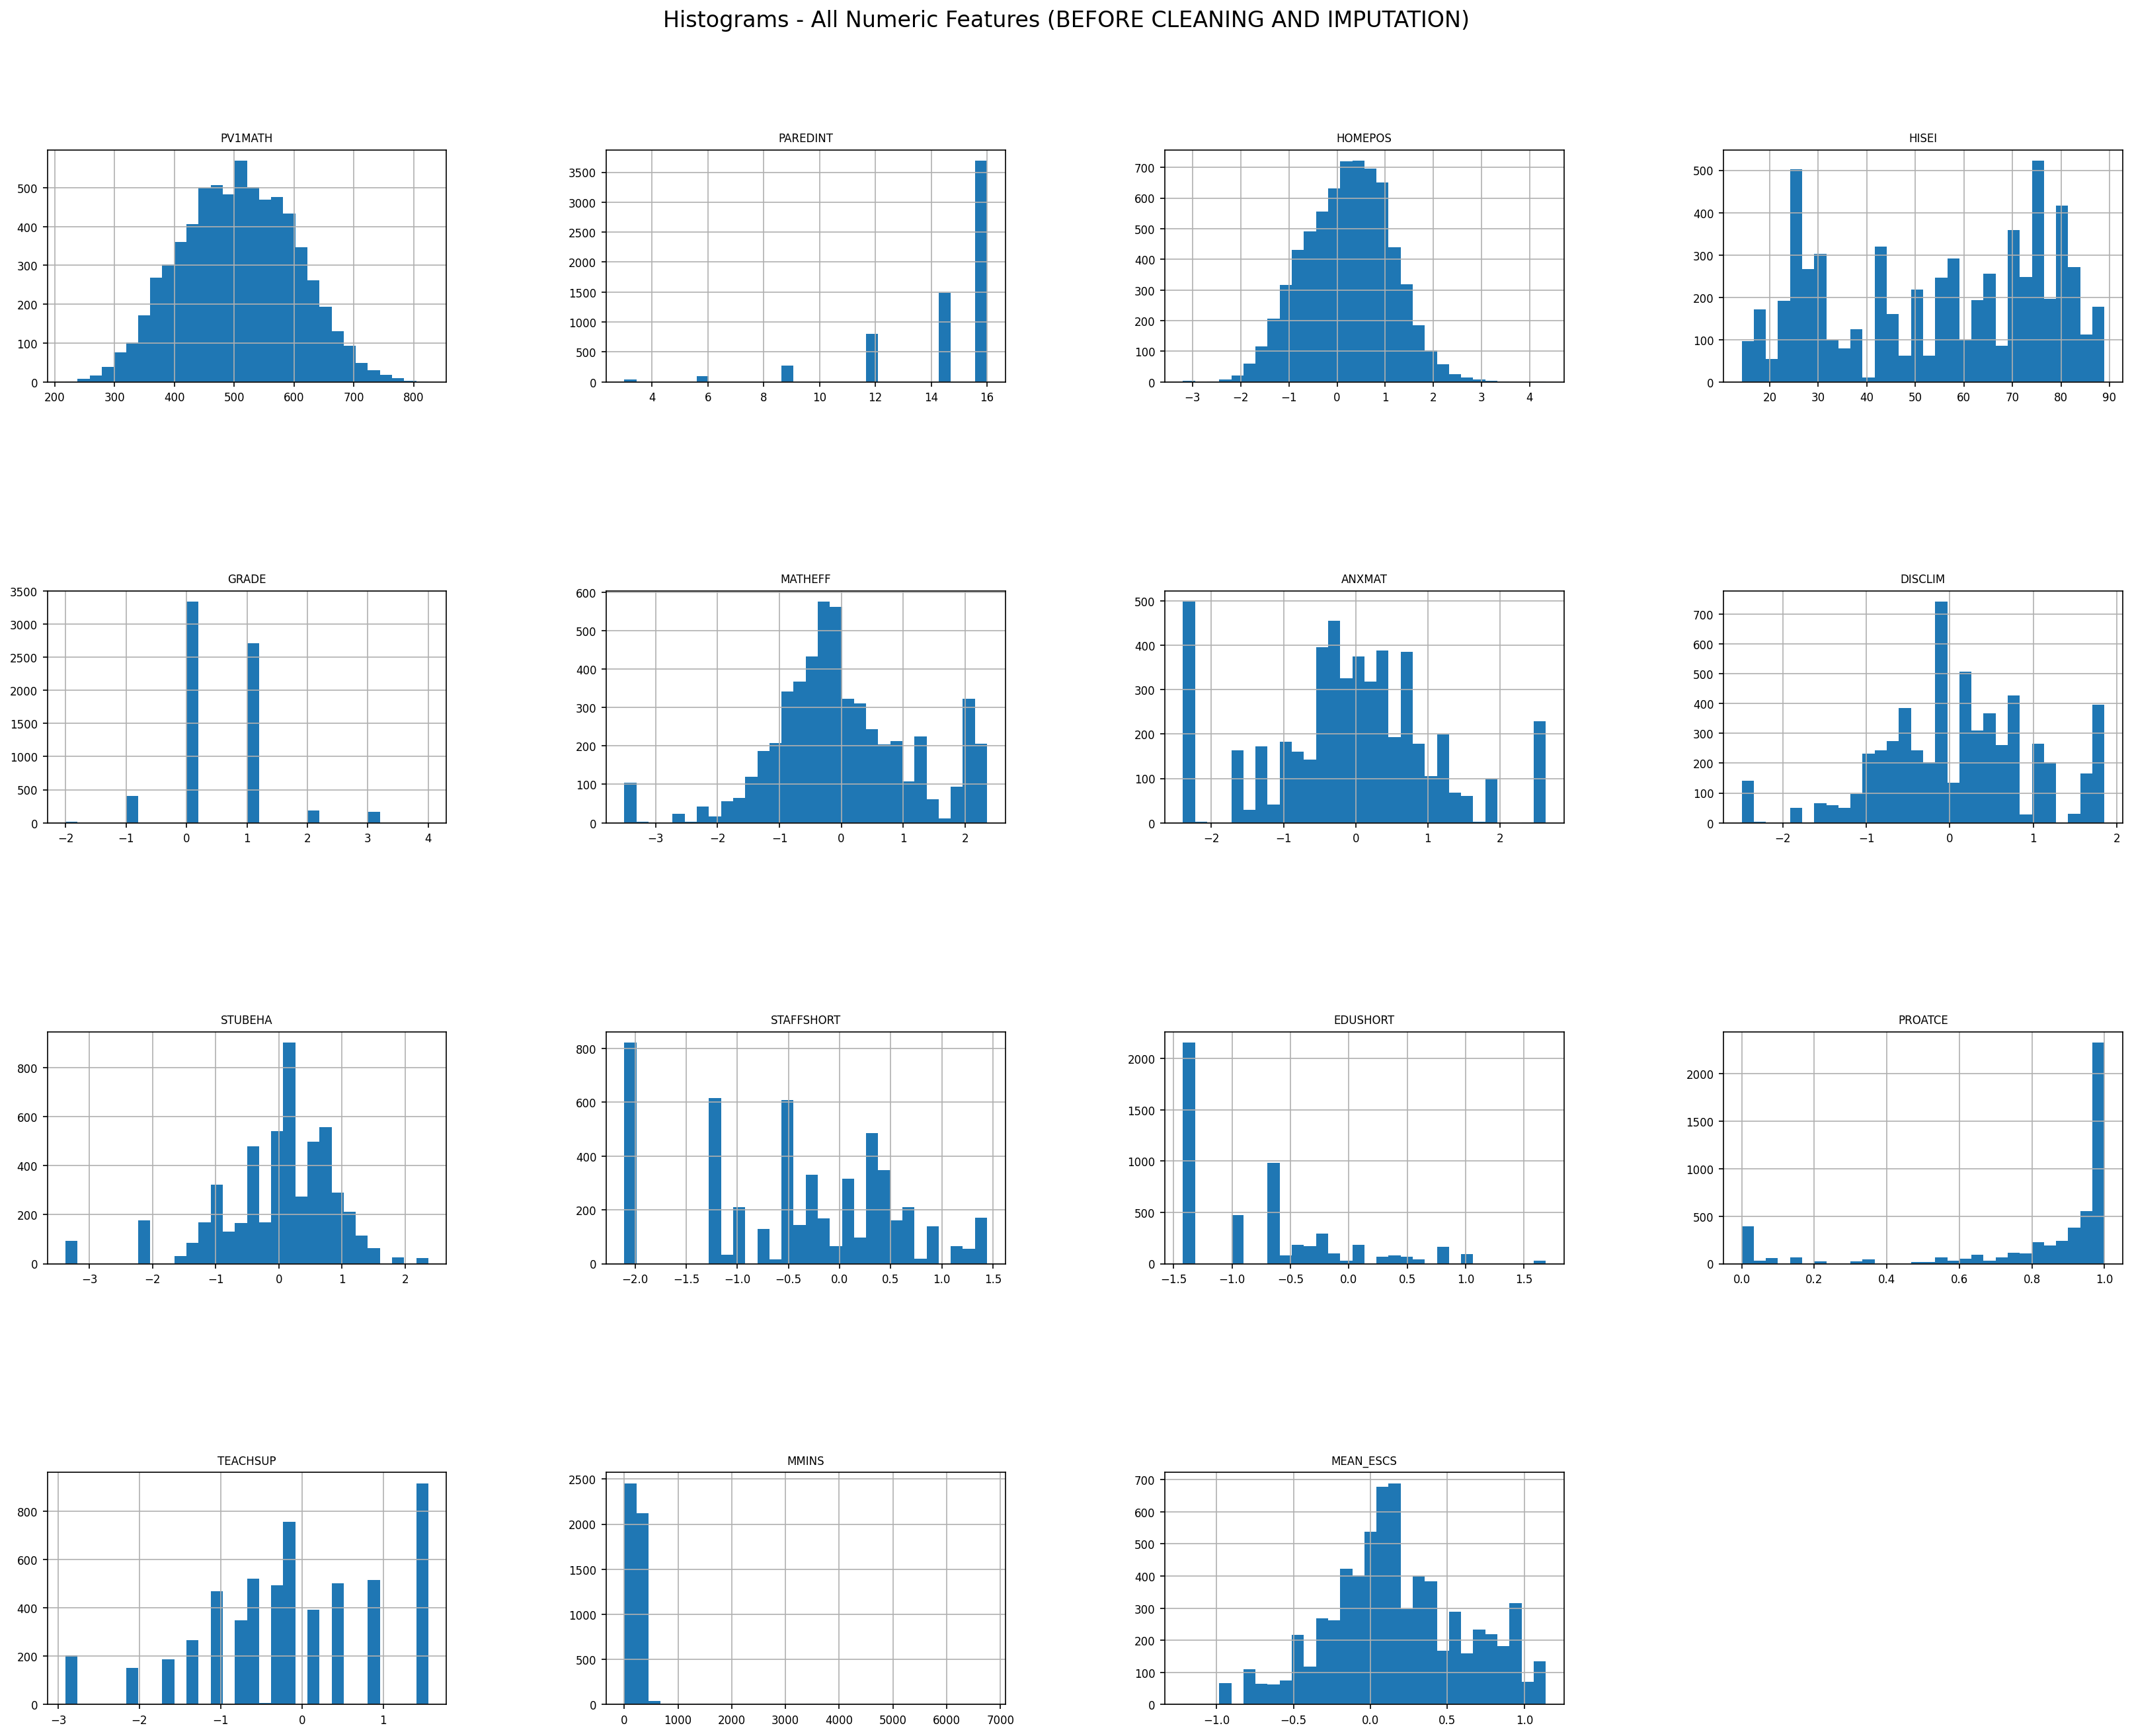


 COMBINED VIOLIN PLOTS FOR ALL NUMERIC FEATURES:


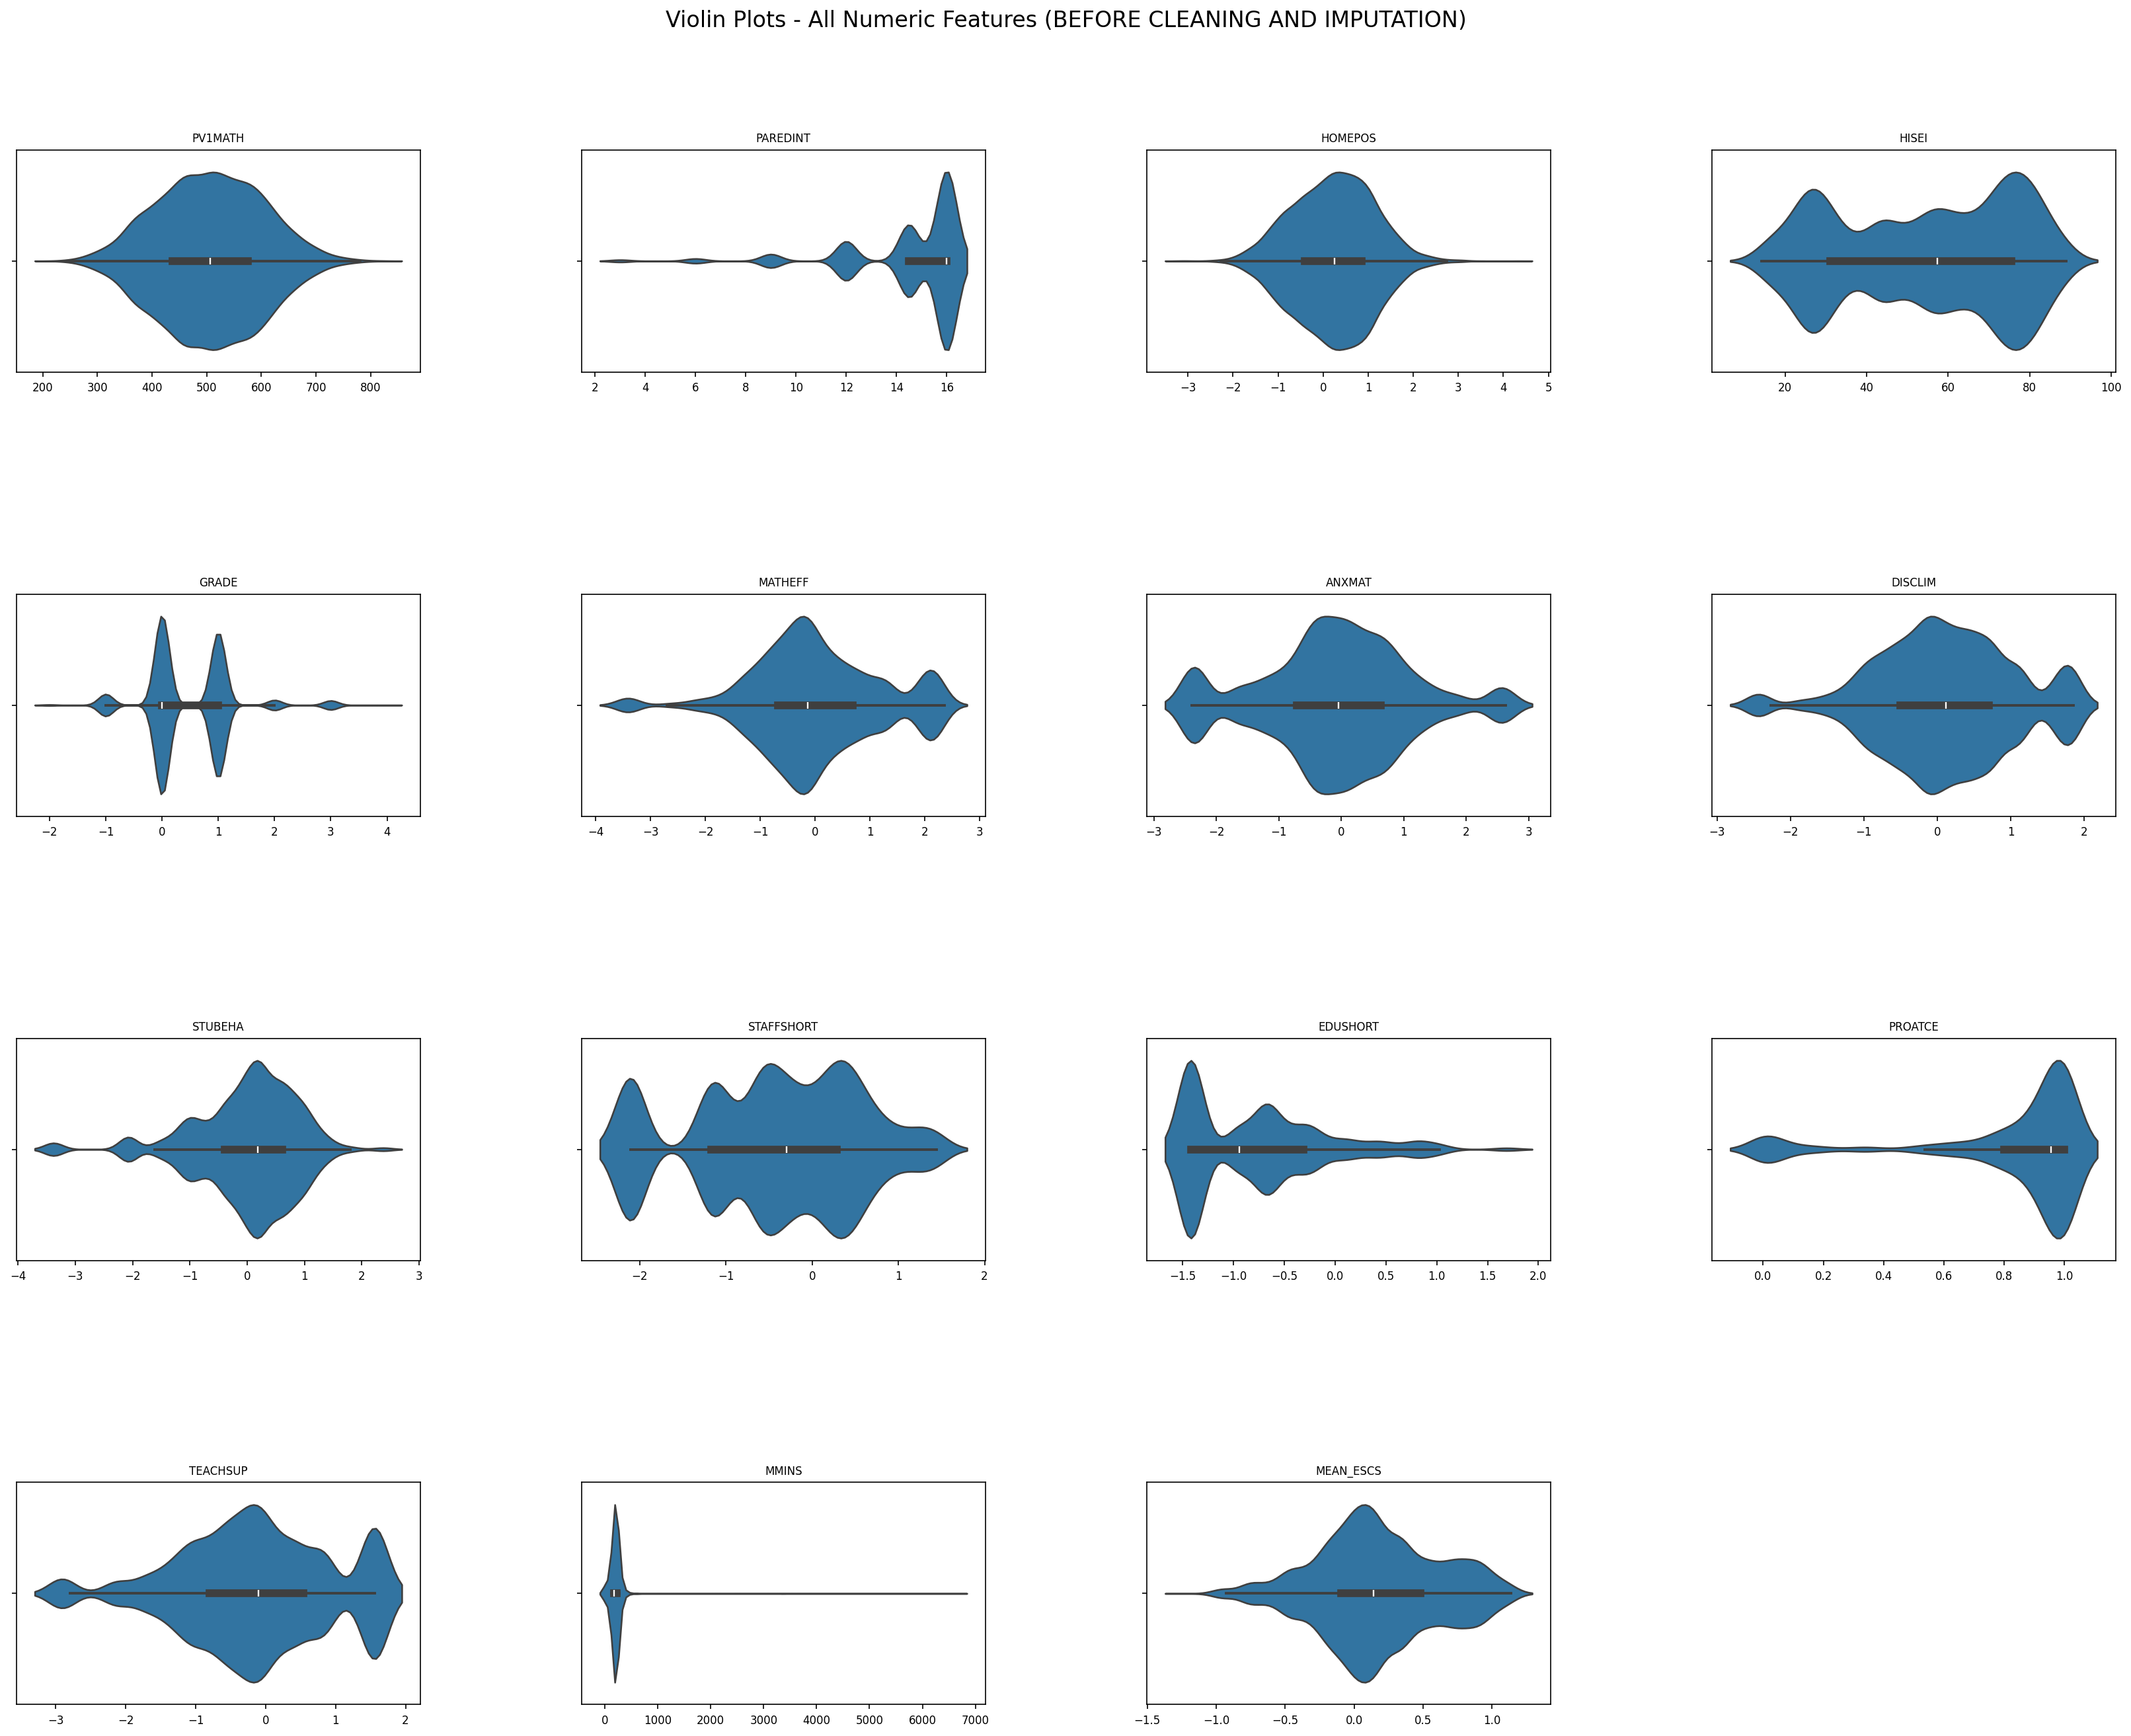

In [3]:
from src.config import MODELS_DIR, OUTPUTS_DIR, PLOTS_DIR, SAVEDFILES_DIR, TABLES_DIR
from src.tables import save_descriptive_statistics, save_missing_values_report
from src.utils import display_visualisation, print_files
from src.visualisations import save_combined_barplots, save_combined_histograms, save_combined_violin_plots, save_individual_barplots, save_individual_histograms, save_individual_violin_plots

for dir_path in [OUTPUTS_DIR, TABLES_DIR, PLOTS_DIR, MODELS_DIR, SAVEDFILES_DIR]:
    os.makedirs(dir_path, exist_ok=True)

# Data analysis: generate tables
save_descriptive_statistics(df_raw_with_correct_features, "GLOBAL DATA EXPLORATORY ANALYSIS (BEFORE CLEANING)")
save_descriptive_statistics(df_preprocessed, "GLOBAL DATA EXPLORATORY ANALYSIS (CLEANED WHOLE DATASET)")
print("Columns removed from training-set missingness:", removed_missing_columns or "None")
save_missing_values_report(df_raw_with_correct_features, MISSING_VALUES_THRESHOLD, "MISSING VALUES REPORT (BEFORE CLEANING)")

# Data analysis: generate plots 
save_individual_histograms(df_raw_with_correct_features, "BEFORE CLEANING")
save_individual_violin_plots(df_raw_with_correct_features, "BEFORE CLEANING")
save_individual_barplots(df_raw_with_correct_features, "BEFORE CLEANING")
save_combined_histograms(df_raw_with_correct_features)
save_combined_violin_plots(df_raw_with_correct_features)
save_combined_barplots(df_raw_with_correct_features)

# Data analysis: display tables and plots
print(f"\n DESCRIPTIVE STATISTICS:")
print_files("outputs/tables/GLOBAL DATA EXPLORATORY ANALYSIS (BEFORE CLEANING).txt")
print(f"\n MISSING VALUES REPORT:")
print_files("outputs/tables/MISSING VALUES REPORT (BEFORE CLEANING).txt")
print(f"\n COMBINED BAR PLOTS FOR ALL CATEGORICAL FEATURES:")
display_visualisation("outputs/plots/univariate_plots/barplots/Bar Plots - All Categorical Features (BEFORE CLEANING AND IMPUTATION).png")
print(f"\n COMBINED HISTOGRAMS FOR ALL NUMERIC FEATURES:")
display_visualisation("outputs/plots/univariate_plots/histograms/Histograms - All Numeric Features (BEFORE CLEANING AND IMPUTATION).png")
print(f"\n COMBINED VIOLIN PLOTS FOR ALL NUMERIC FEATURES:")
display_visualisation("outputs/plots/univariate_plots/violin_plots/Violin Plots - All Numeric Features (BEFORE CLEANING AND IMPUTATION).png")


##### **IV. EXPLORATORY DATA ANALYSIS ON TRAIN-SET AFTER IMPUTATION**

This step performs an exploratory analysis of the training dataset after imputation to identify correlations among the variables (potential multicollinearity) as well as correlations between the variables and the target variable (PV1MATH). 

The goal is to identify the variables that appear to be most strongly associated with the target variable prior to variable selection.

SPEARMAN CORRELATION MATRIX (TRAIN SET AFTER IMPUTATION).png saved to outputs/plots/multivariate_plots/
correlations_with_PV1MATH.txt saved to outputs/tables/correlations_with_PV1MATH.txt
correlations_among_features.txt saved to outputs/tables/correlations_among_features.txt


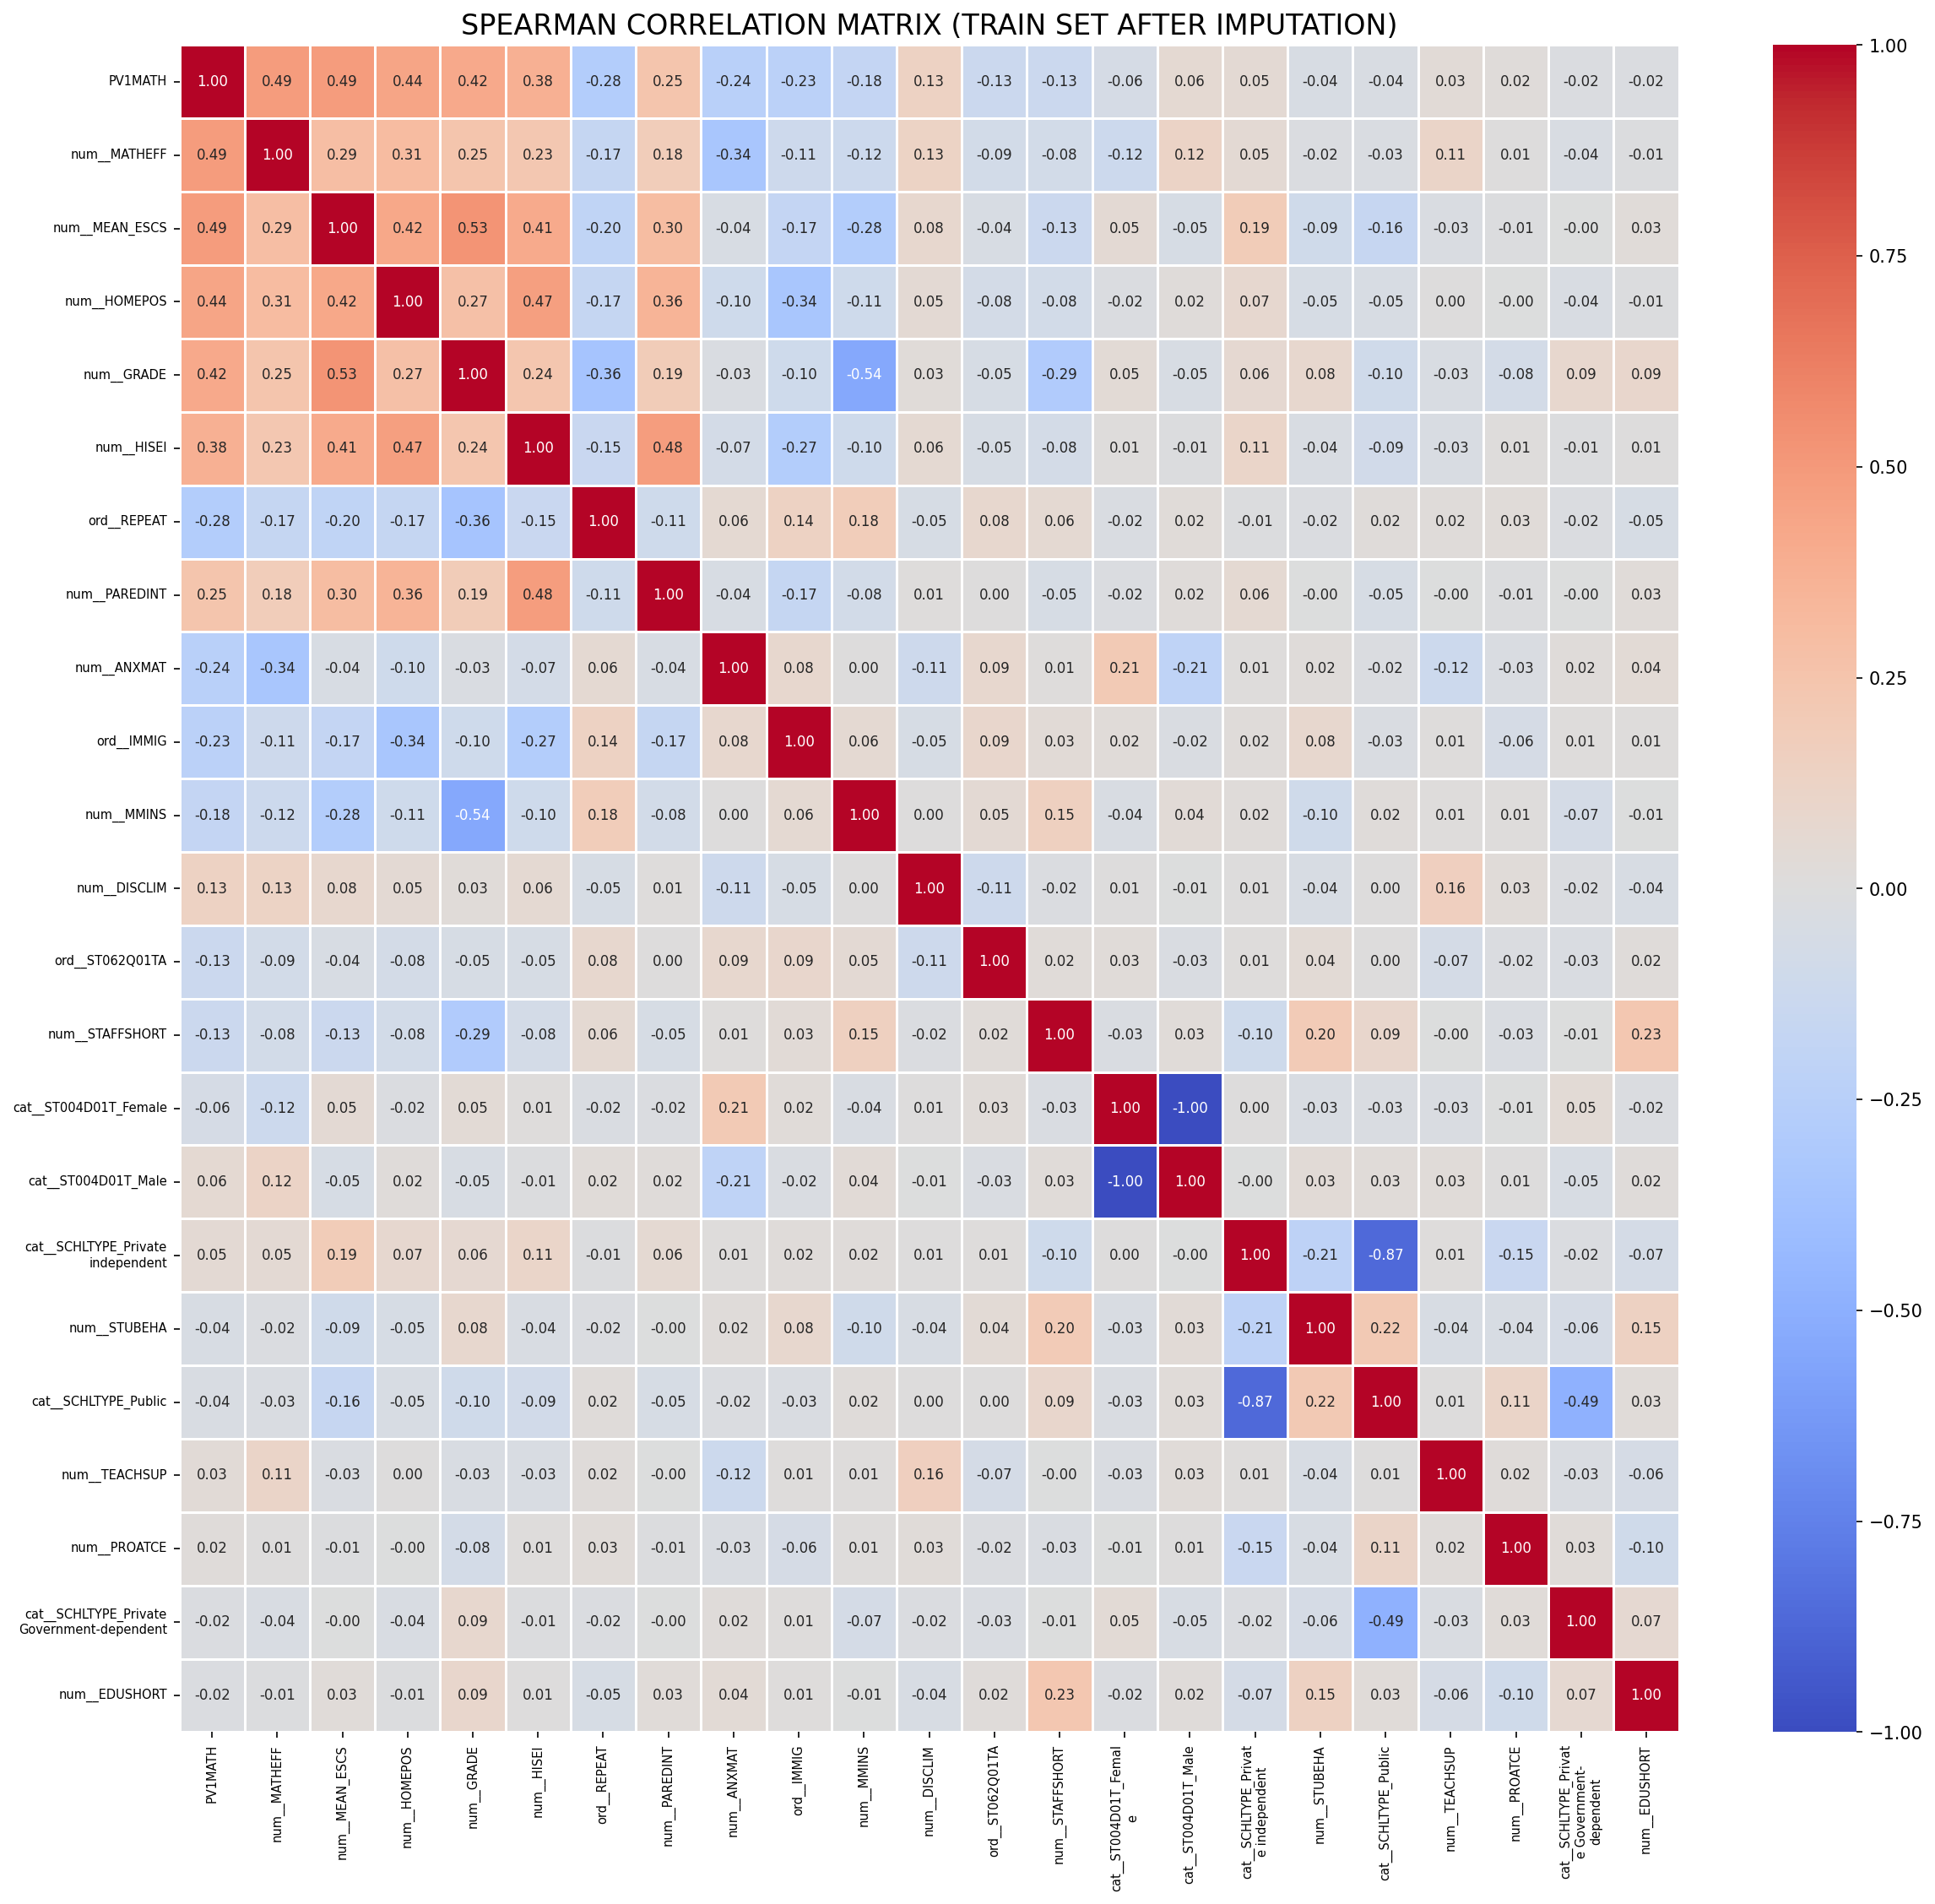


CORRELATIONS WITH TARGET

POSITIVE CORRELATIONS WITH PV1MATH
                                   Correlation
Feature                                       
num__MATHEFF                          0.490289
num__MEAN_ESCS                        0.487596
num__HOMEPOS                          0.438485
num__GRADE                            0.418406
num__HISEI                            0.377014
num__PAREDINT                         0.248540
num__DISCLIM                          0.132944
cat__ST004D01T_Male                   0.060256
cat__SCHLTYPE_Private independent     0.051404
num__TEACHSUP                         0.034768
num__PROATCE                          0.022095

NEGATIVE CORRELATIONS WITH PV1MATH
                                            Correlation
Feature                                                
ord__REPEAT                                   -0.277054
num__ANXMAT                                   -0.244150
ord__IMMIG                                    -0.230720
num__MMINS 

In [4]:
from src.dataset_cleaning_and_preprocessing import create_eda_preprocessor, create_imputed_dataframe
from src.tables import save_correlations_among_features, save_correlations_with_target
from src.visualisations import save_spearman_correlation_matrix

eda_preprocessor = create_eda_preprocessor(X_train)
X_train_imputed_for_eda = eda_preprocessor.fit_transform(X_train)

df_train_set_for_eda = create_imputed_dataframe(
X_train_imputed_for_eda,
eda_preprocessor,
y_train,
)

# Data analysis: generate and save correlation computations
save_spearman_correlation_matrix(df_train_set_for_eda, "SPEARMAN CORRELATION MATRIX (TRAIN SET AFTER IMPUTATION)")
save_correlations_with_target(df_train_set_for_eda, "PV1MATH")
save_correlations_among_features(df_train_set_for_eda, "PV1MATH")

# Data analysis: display correlation tables and correlation matrix
display_visualisation("outputs/plots/multivariate_plots/SPEARMAN CORRELATION MATRIX (TRAIN SET AFTER IMPUTATION).png")
print_files("outputs/tables/correlations_with_PV1MATH.txt")
print_files("outputs/tables/correlations_between_features.txt")


##### **V. FEATURE SELECTION (FOR CLASSIFICATION AND REGRESSION TASKS)**

This step handles the feature selection process separately for both the classification and regression tasks.

For the classification task, PV1MATH is converted into categorical classes according to the thresholds defined in config.py. Those thresholds are based on the literature. For both tasks, the feature selection pipeline is then applied in the following order:

1. Variance Threshold (currently set to 0 to compute feature variances and remove constant features, if any)
2. Mutual Information
3. ANOVA
4. Recursive Feature Elimination (RFE)

For Mutual Information, ANOVA, and RFE, a ranking of all features is established. Moreover, a global ranking is derived by combining these three rankings. The final feature selection decision is then made based on this global ranking.

Finally, feature selection decisions are based only on the training set (to avoid data leakage) but are applied to both the training and test sets.



In [5]:
#y_train/test for classification task
from src.config import CLASS_BOUNDARIES, CLASS_LABELS
from src.feature_selection import run_feature_selection_pipeline

y_train_class = pd.cut(y_train, bins = CLASS_BOUNDARIES, labels = CLASS_LABELS, right = False, include_lowest = True)
y_test_class = pd.cut(y_test,bins = CLASS_BOUNDARIES, labels = CLASS_LABELS, right = False, include_lowest = True)

# regression
(final_features_ranking_reg, 
 variance_threshold_df_reg, 
 ranking_MI_df_reg, 
 ranking_anova_df_reg, 
 ranking_rfe_df_reg, 
 X_train_after_var_thresh_reg, 
 X_test_after_var_thresh_reg, 
 selected_columns_var_thresh_reg) = run_feature_selection_pipeline(X_train_imputed, 
                                                                   X_test_imputed, 
                                                                   y_train, 
                                                                   all_imputed_feature_names, 
                                                                   task = "regression")

#classification
(final_features_ranking_class, 
 variance_threshold_df_class, 
 ranking_MI_df_class, 
 ranking_anova_df_class, 
 ranking_rfe_df_class, 
 X_train_after_var_thresh_class, 
 X_test_after_var_thresh_class, 
 selected_columns_var_thresh_class) = run_feature_selection_pipeline(X_train_imputed, 
                                                                     X_test_imputed, 
                                                                     y_train_class, 
                                                                     all_imputed_feature_names, 
                                                                     task = "classification")

print_files("outputs/tables/variance_threshold_ranking.txt")
print("=" * 80)
print(f"REGRESSION TASK:")
print("=" * 80)
print_files("outputs/tables/regression_mutual_info_ranking.txt")
print_files("outputs/tables/regression_anova_ranking.txt")
print_files("outputs/tables/regression_rfe_ranking.txt")
print_files("outputs/tables/regression_combined_feature_selection_rankings.txt")
print("=" * 80)
print(f"CLASSIFICATION TASK:")
print("=" * 80)
print_files("outputs/tables/classification_mutual_info_ranking.txt")
print_files("outputs/tables/classification_anova_ranking.txt")
print_files("outputs/tables/classification_rfe_ranking.txt")
print_files("outputs/tables/classification_combined_feature_selection_rankings.txt")


variance_threshold_ranking.txt saved to outputs/tables
regression_mutual_info_ranking.txt saved to outputs/tables
regression_anova_ranking.txt saved to outputs/tables
regression_rfe_ranking.txt saved to outputs/tables
regression_combined_feature_selection_rankings.txt saved to outputs/tables
variance_threshold_ranking.txt saved to outputs/tables
classification_mutual_info_ranking.txt saved to outputs/tables
classification_anova_ranking.txt saved to outputs/tables
classification_rfe_ranking.txt saved to outputs/tables
classification_combined_feature_selection_rankings.txt saved to outputs/tables

Variance Threshold (threshold = 0) : 20/20 kept

                          Feature    Variance Status
                       num__MMINS 4770.041073   KEPT
                       num__HISEI  452.358075   KEPT
                    num__PAREDINT    5.258476   KEPT
                     num__MATHEFF    1.112848   KEPT
                      num__ANXMAT    1.098859   KEPT
                    num__TEACH

##### **VI.I MODEL TRAINING FOR REGRESSION TASK**

This stage trains and evaluates four regression models:
1. Linear Regression
2. Random Forest
3. XGBoost 
4. Support Vector Regression 

It uses different numbers of selected variables (the top 5, 10, 15 and 20 variables). Model selection is based primarily on the best score obtained via 5-fold cross-validation on the training dataset, following hyperparameter optimisation. 

The final models are then evaluated on an independent test set to assess their generalisation ability. Finally, detailed results, summary tables and diagnostic plots are generated to compare the models and identify the optimal number of variables.



############################################################
# TESTING K = 5 FEATURES
############################################################

Training LR (Regressor)
Best alpha        : 0.01
Features selected : 5/5

Training RF (Regressor)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Training XGBoost (Regressor)
Fitting 3 folds for each of 128 candidates, totalling 384 fits

Training SVR (Regressor)
Fitting 3 folds for each of 72 candidates, totalling 216 fits

############################################################
# TESTING K = 10 FEATURES
############################################################

Training LR (Regressor)
Best alpha        : 0.1
Features selected : 10/10

Training RF (Regressor)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Training XGBoost (Regressor)
Fitting 3 folds for each of 128 candidates, totalling 384 fits

Training SVR (Regressor)
Fitting 3 folds for each of 72 candidates, totalling 216 fits

###################

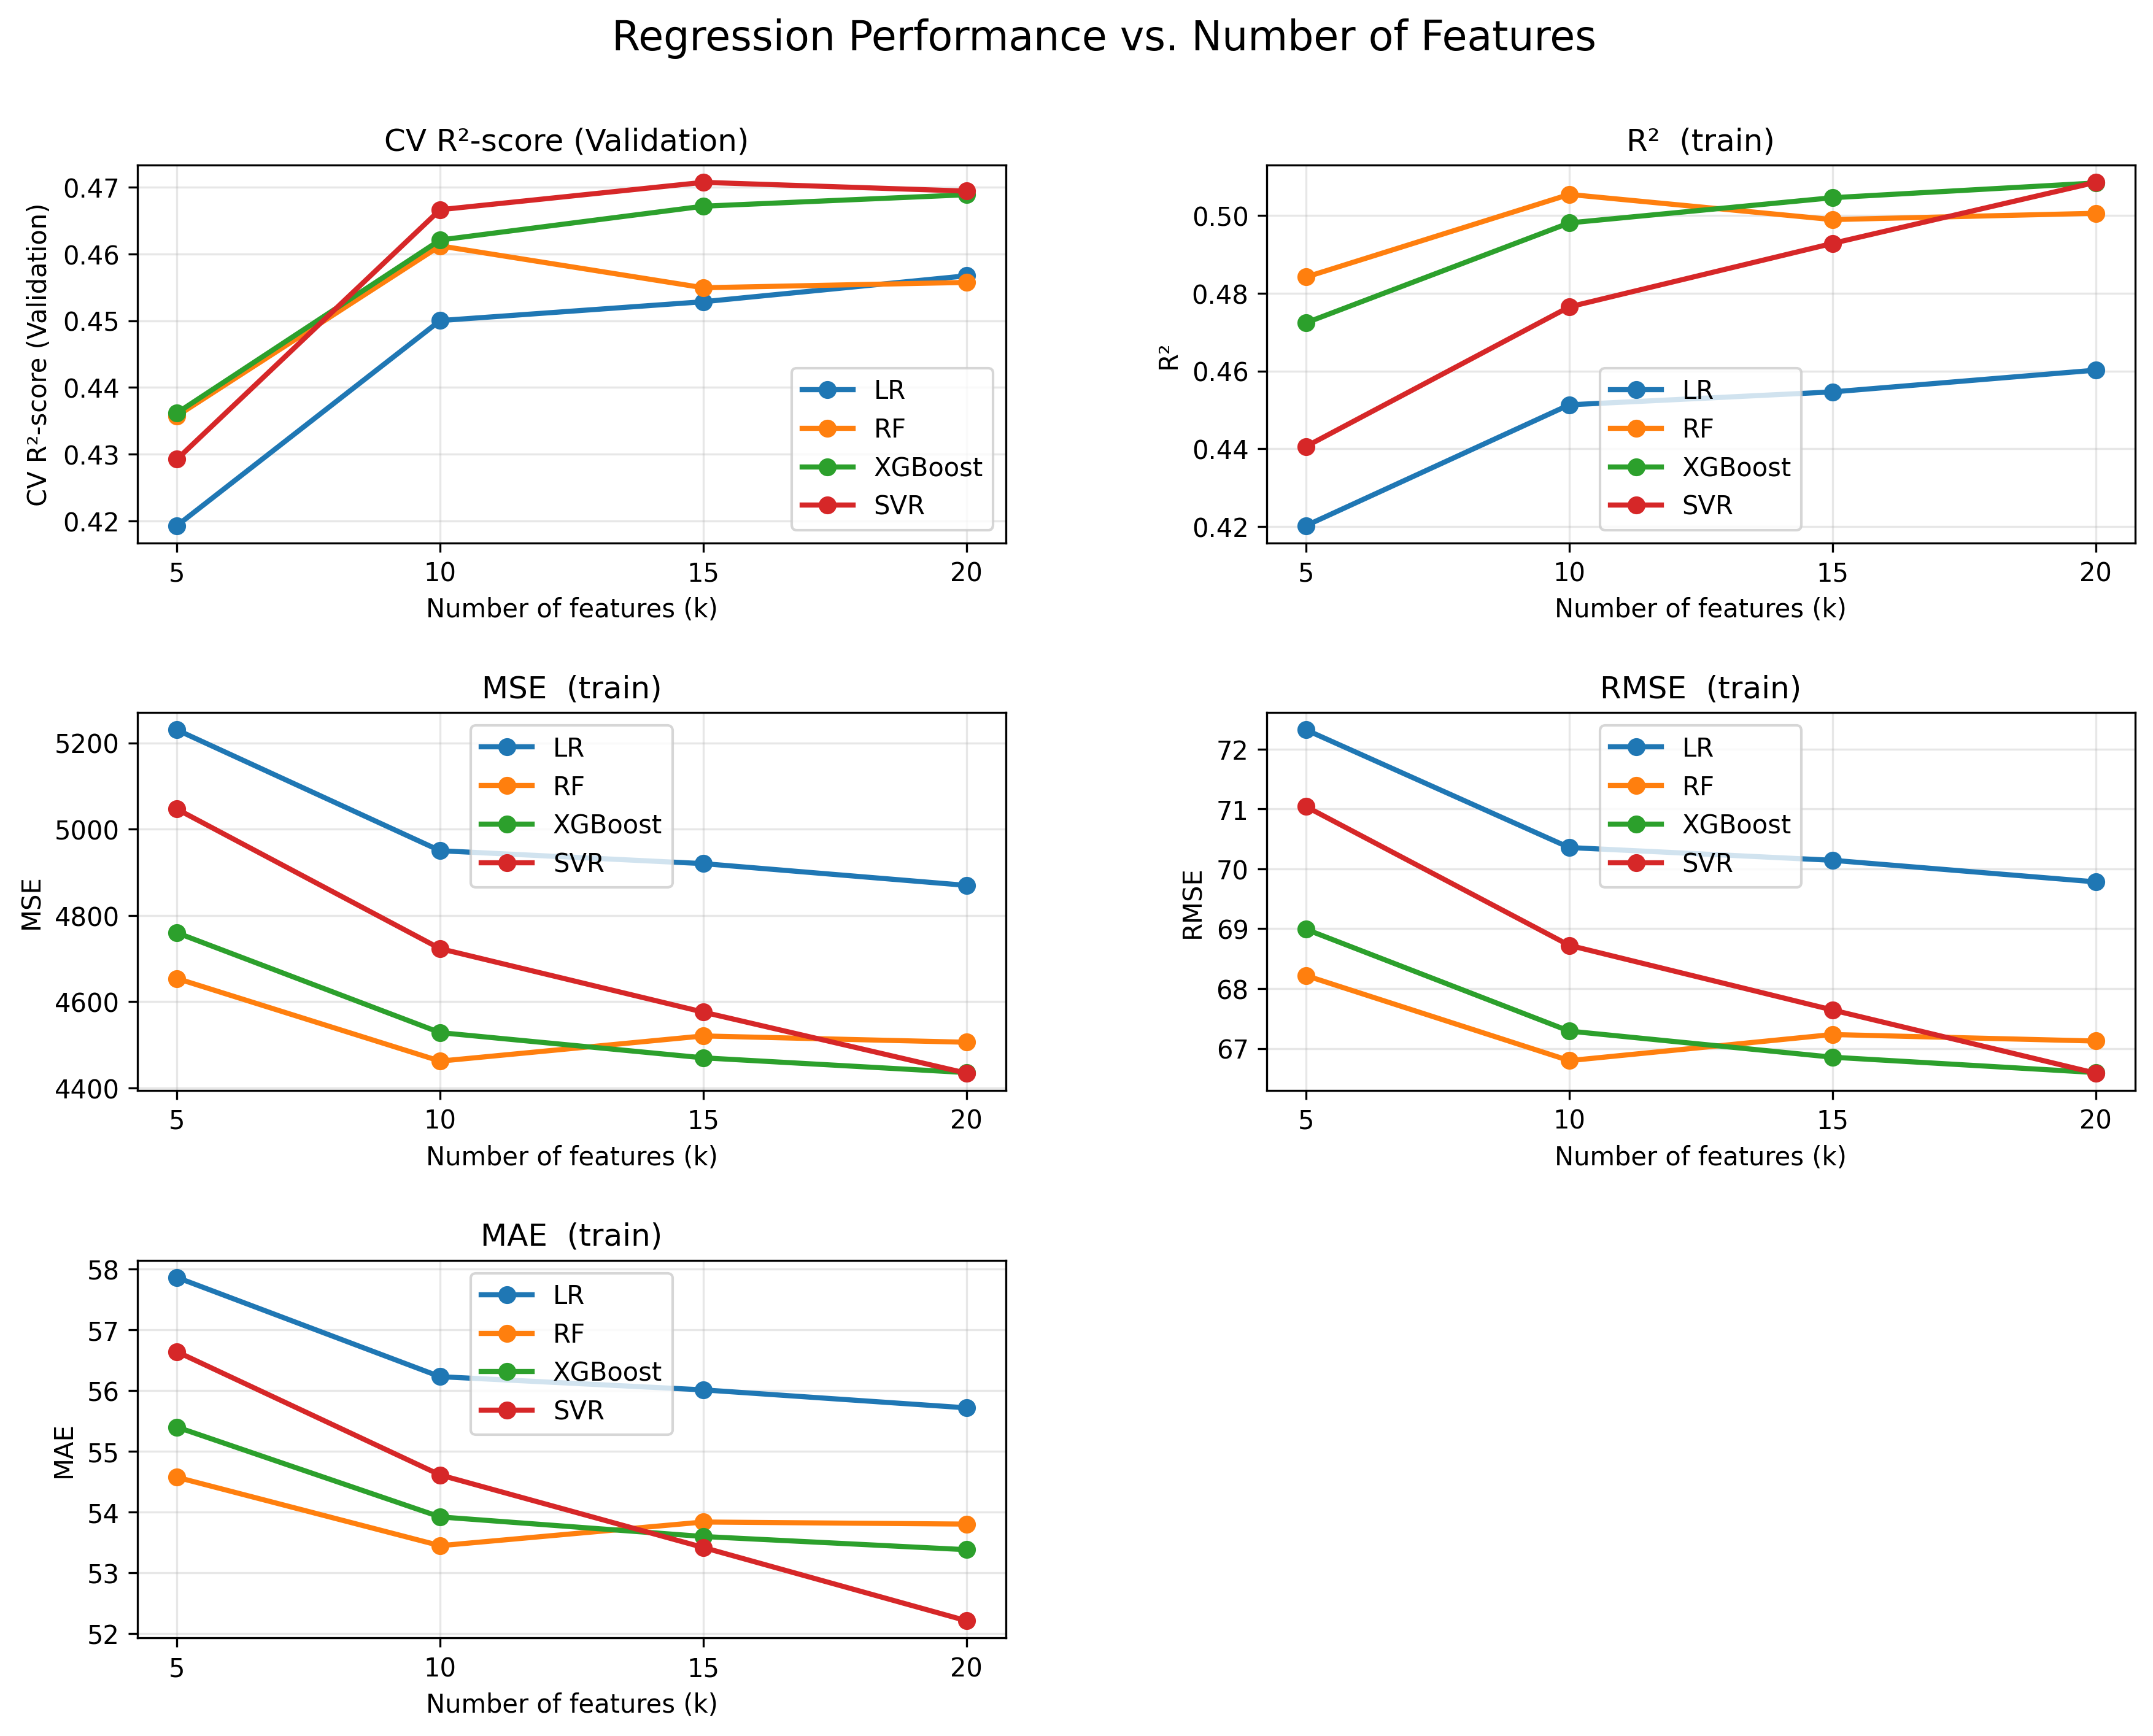

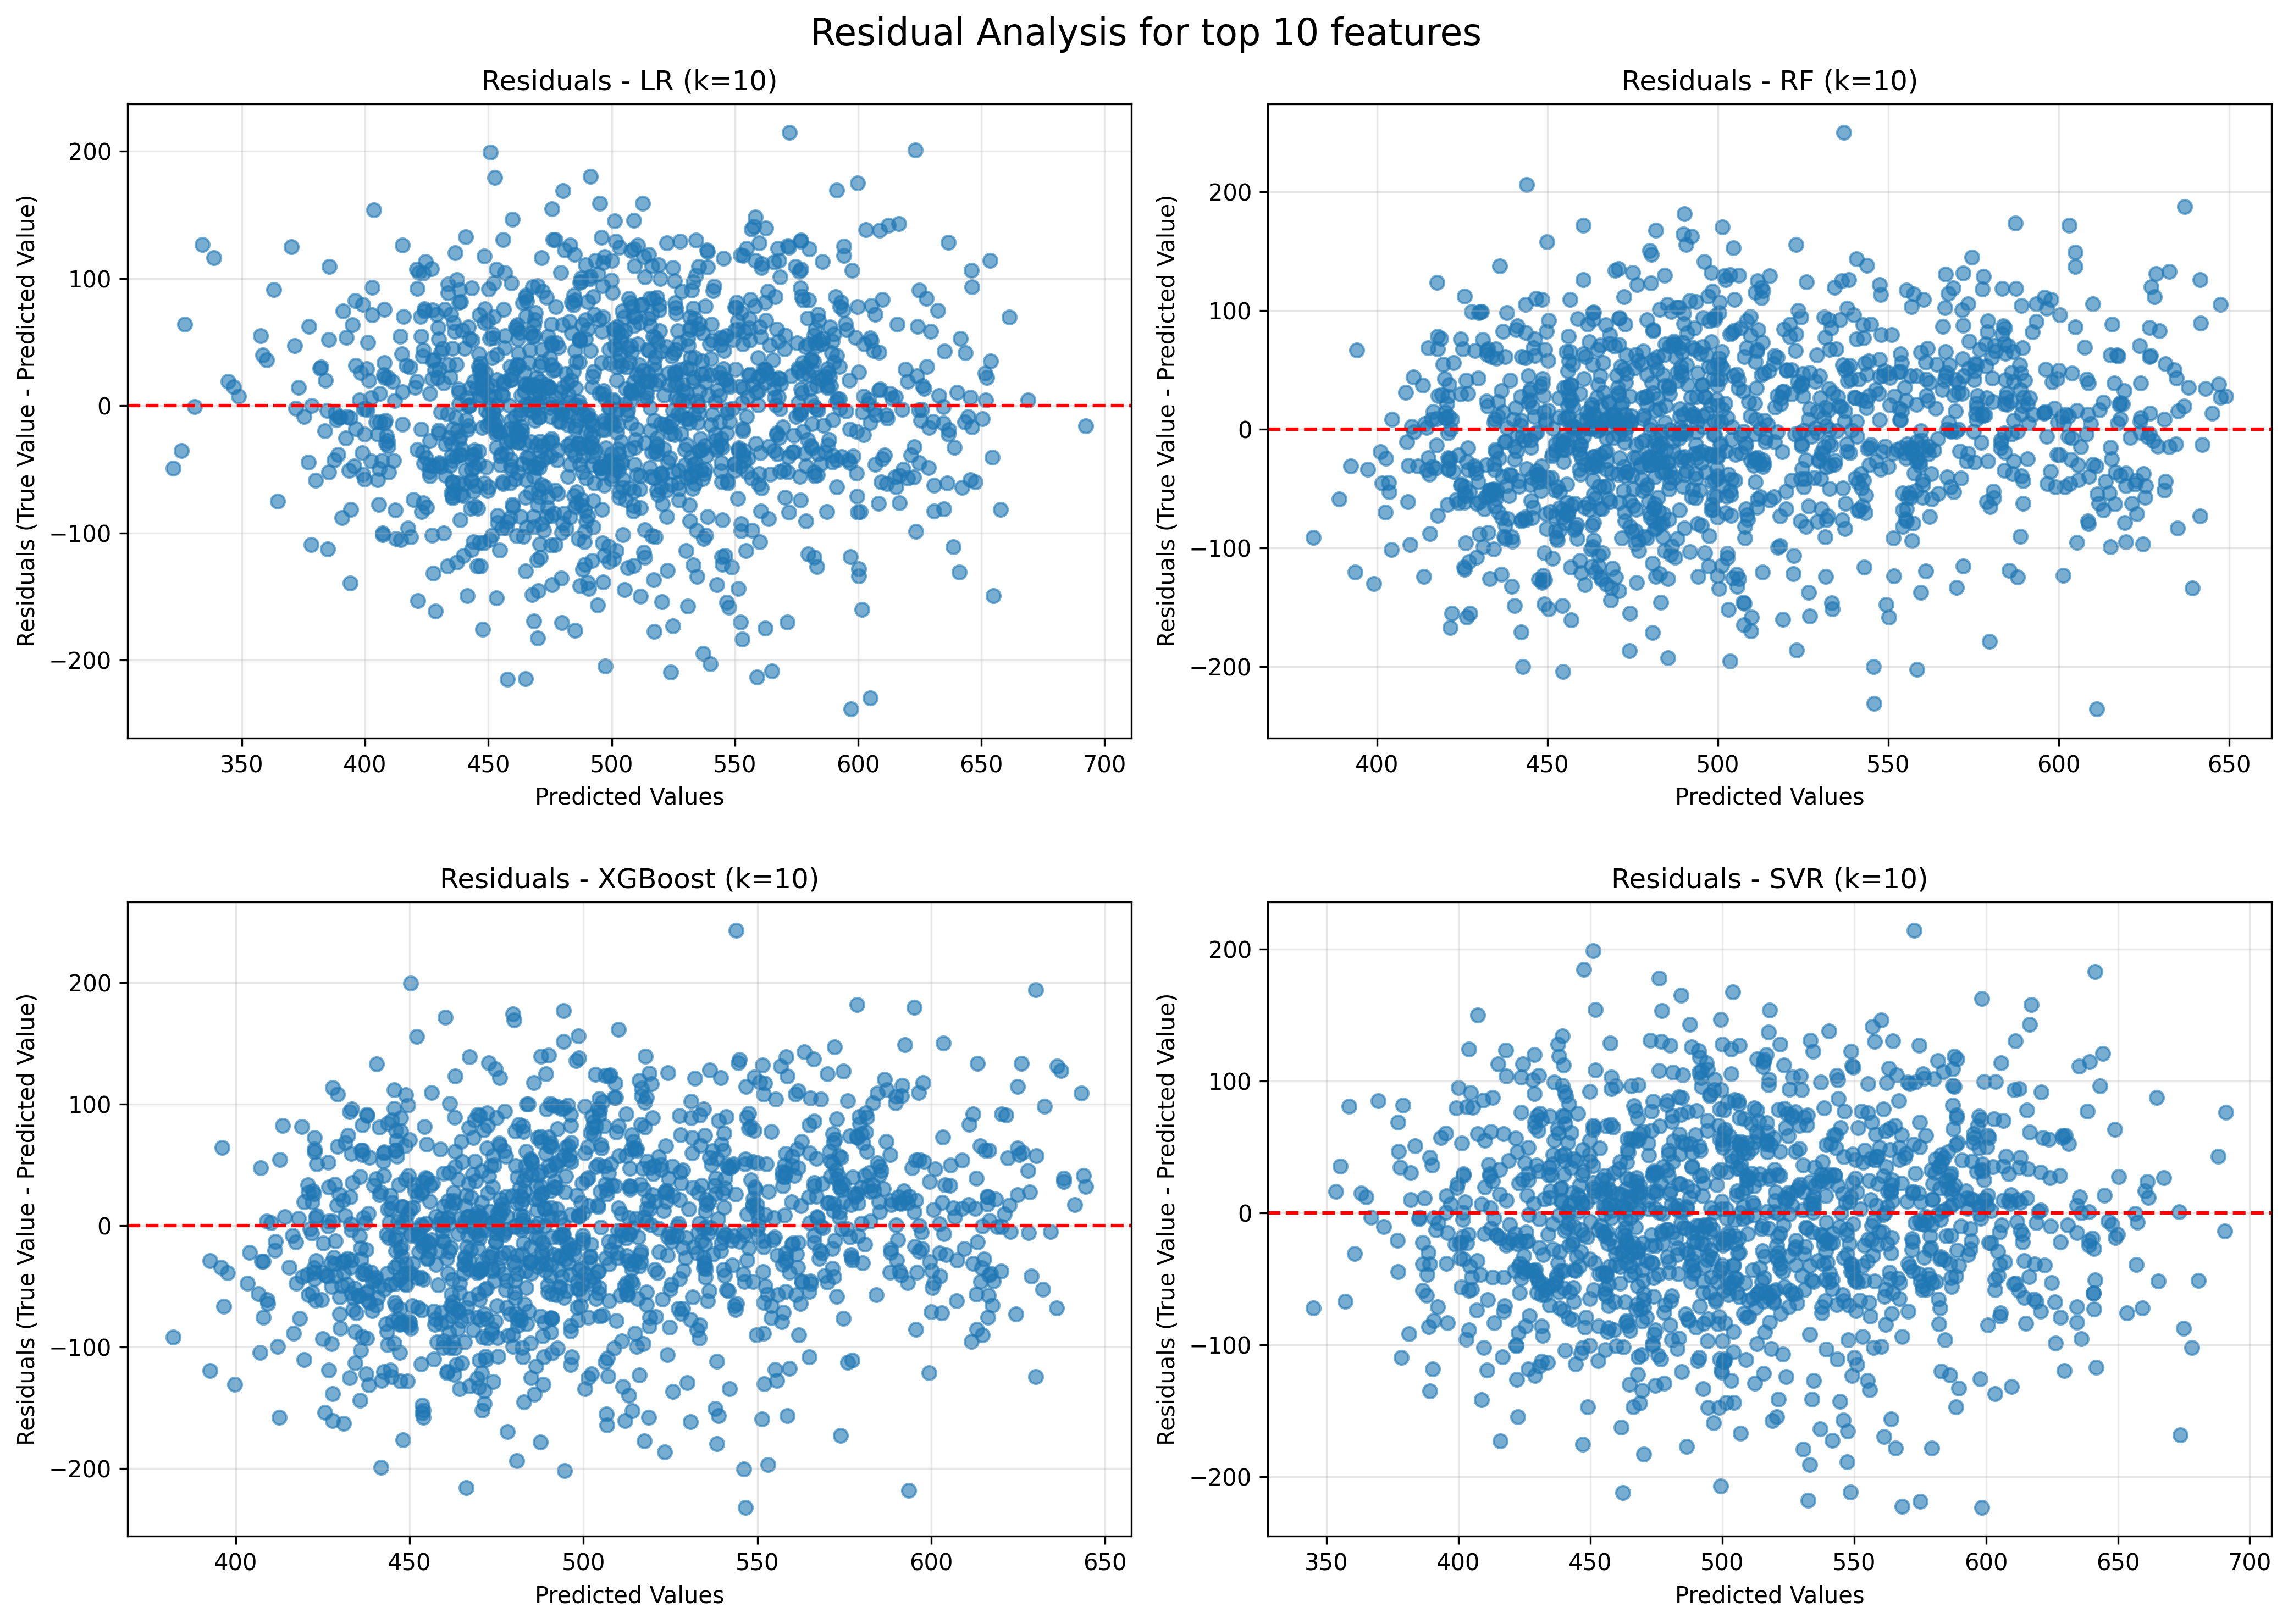

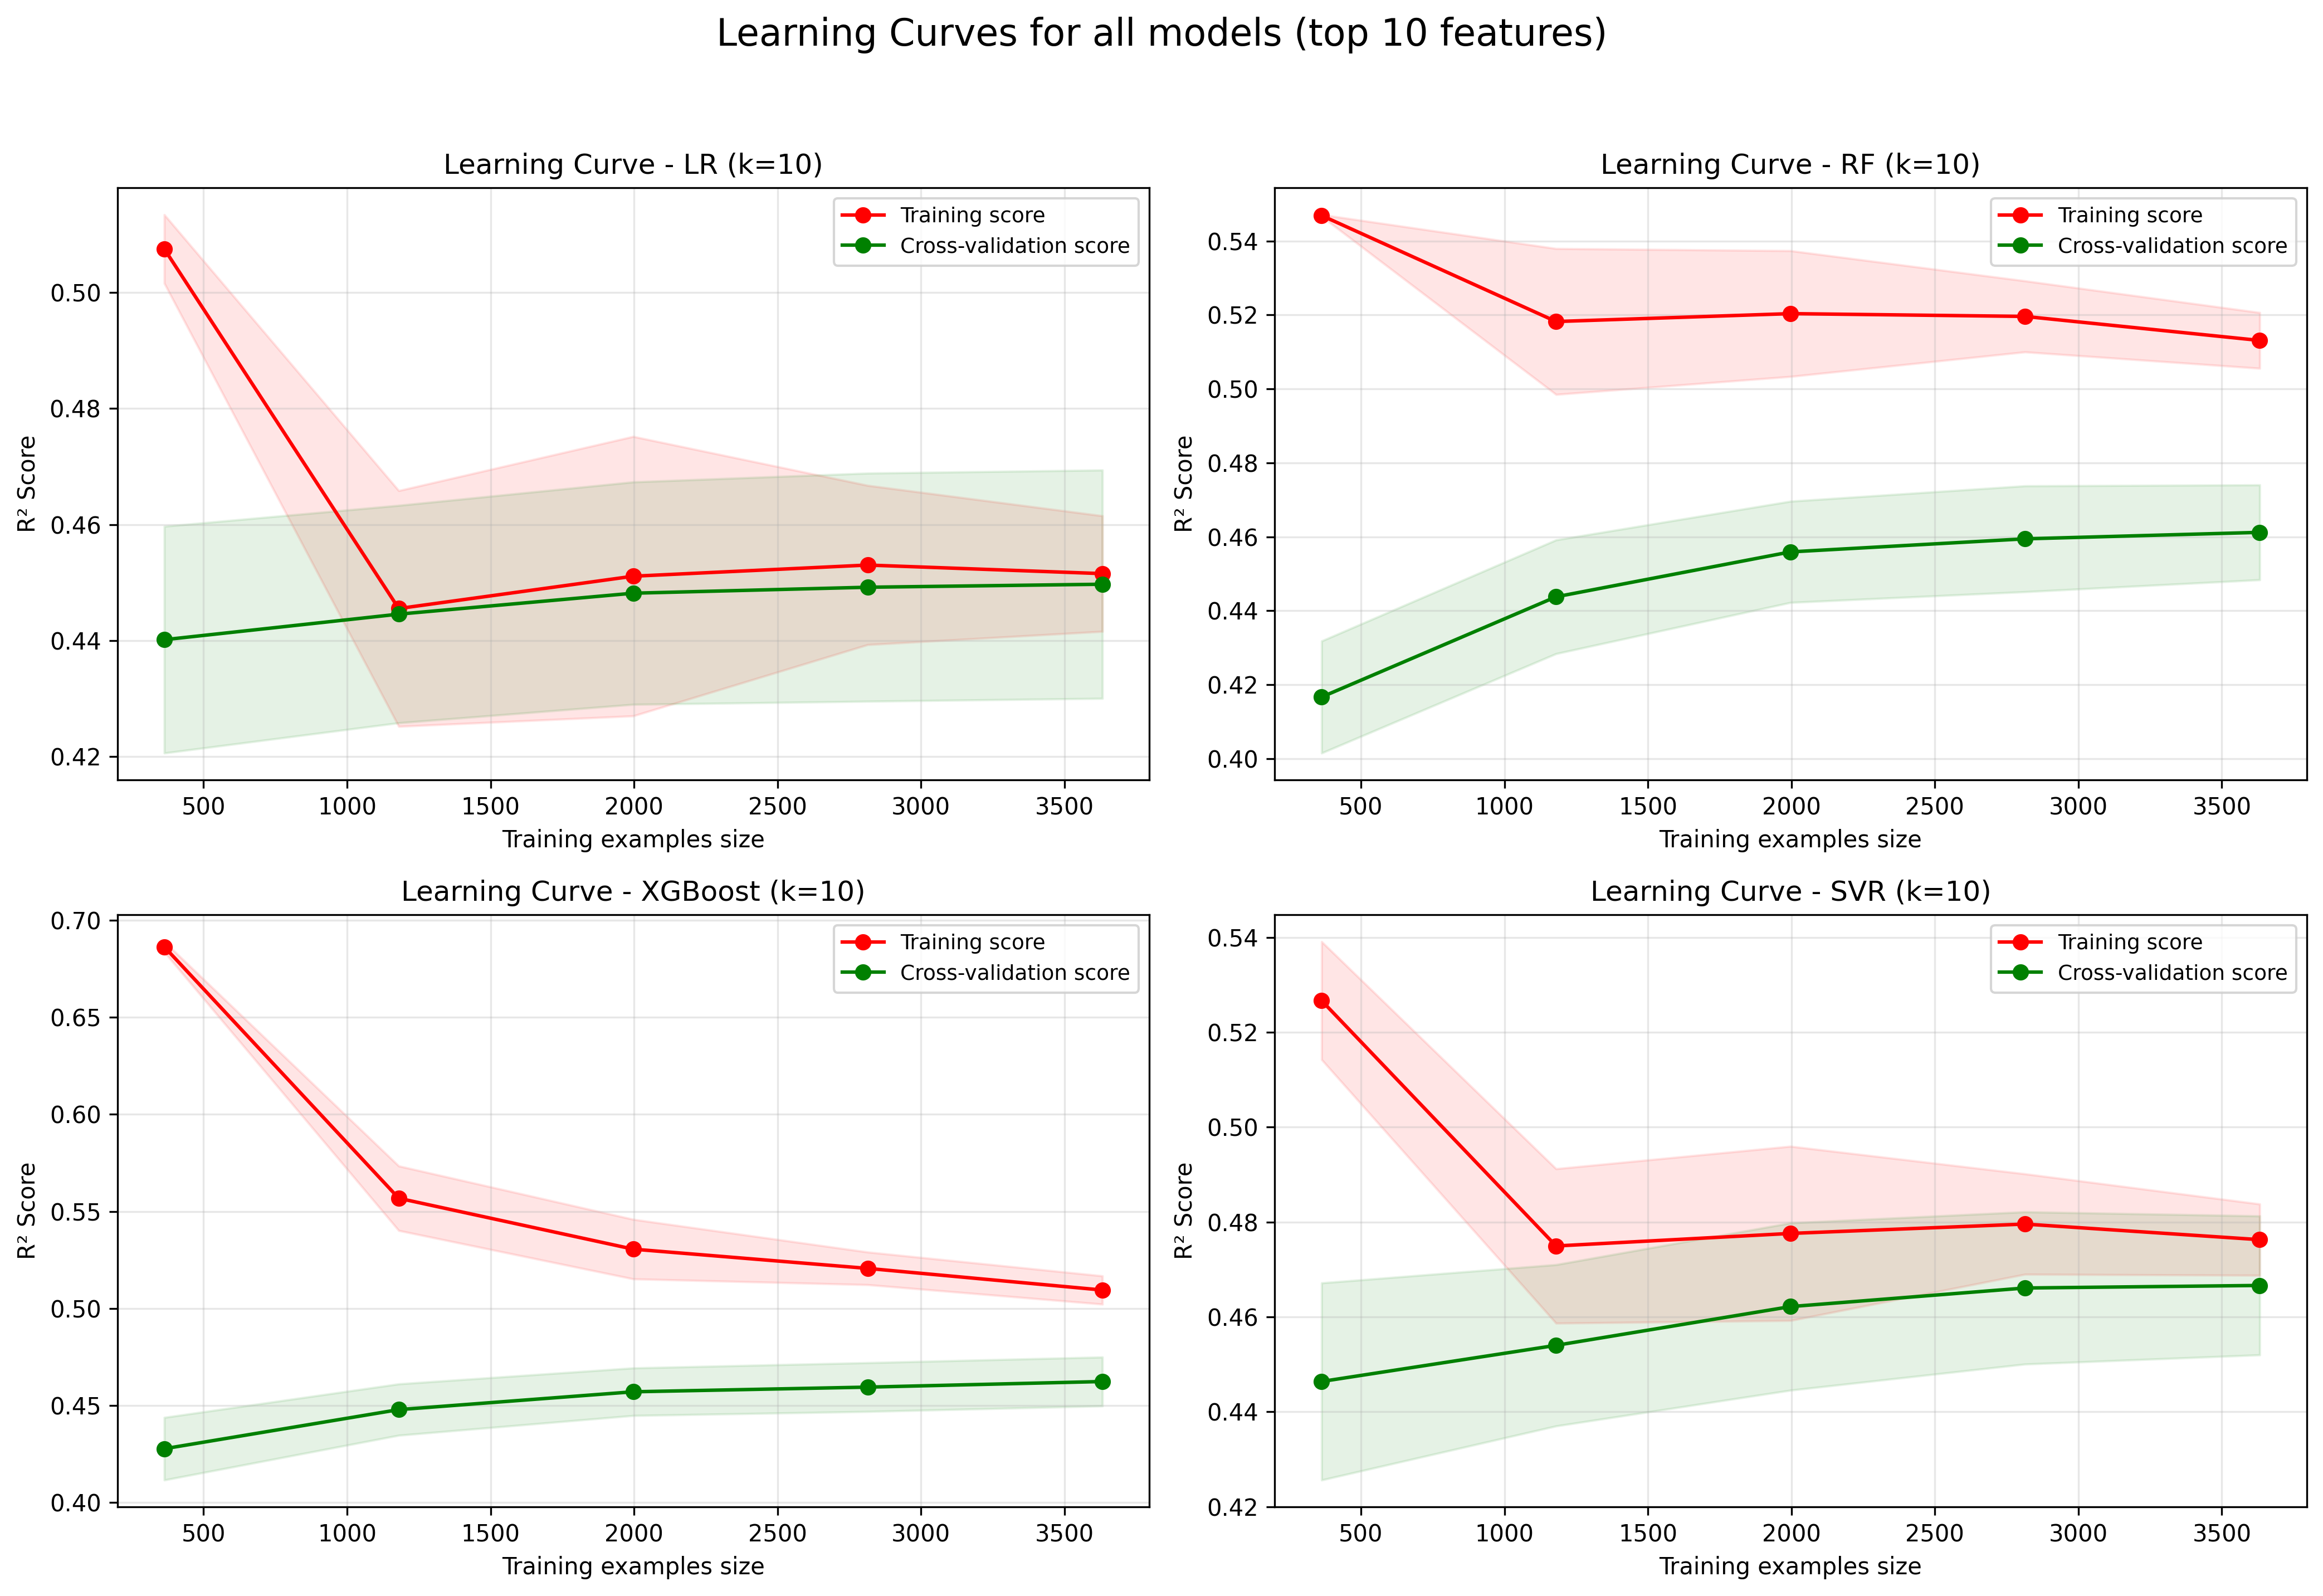

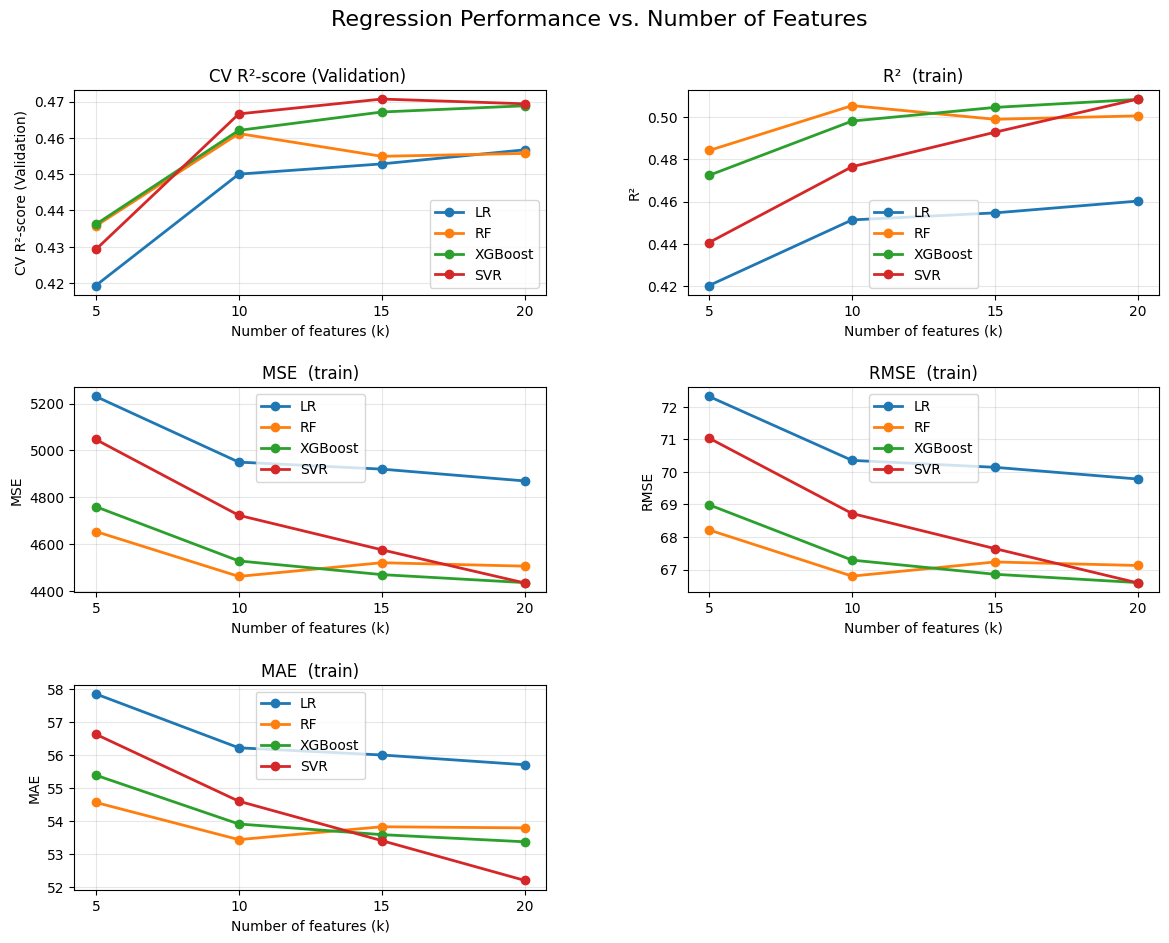

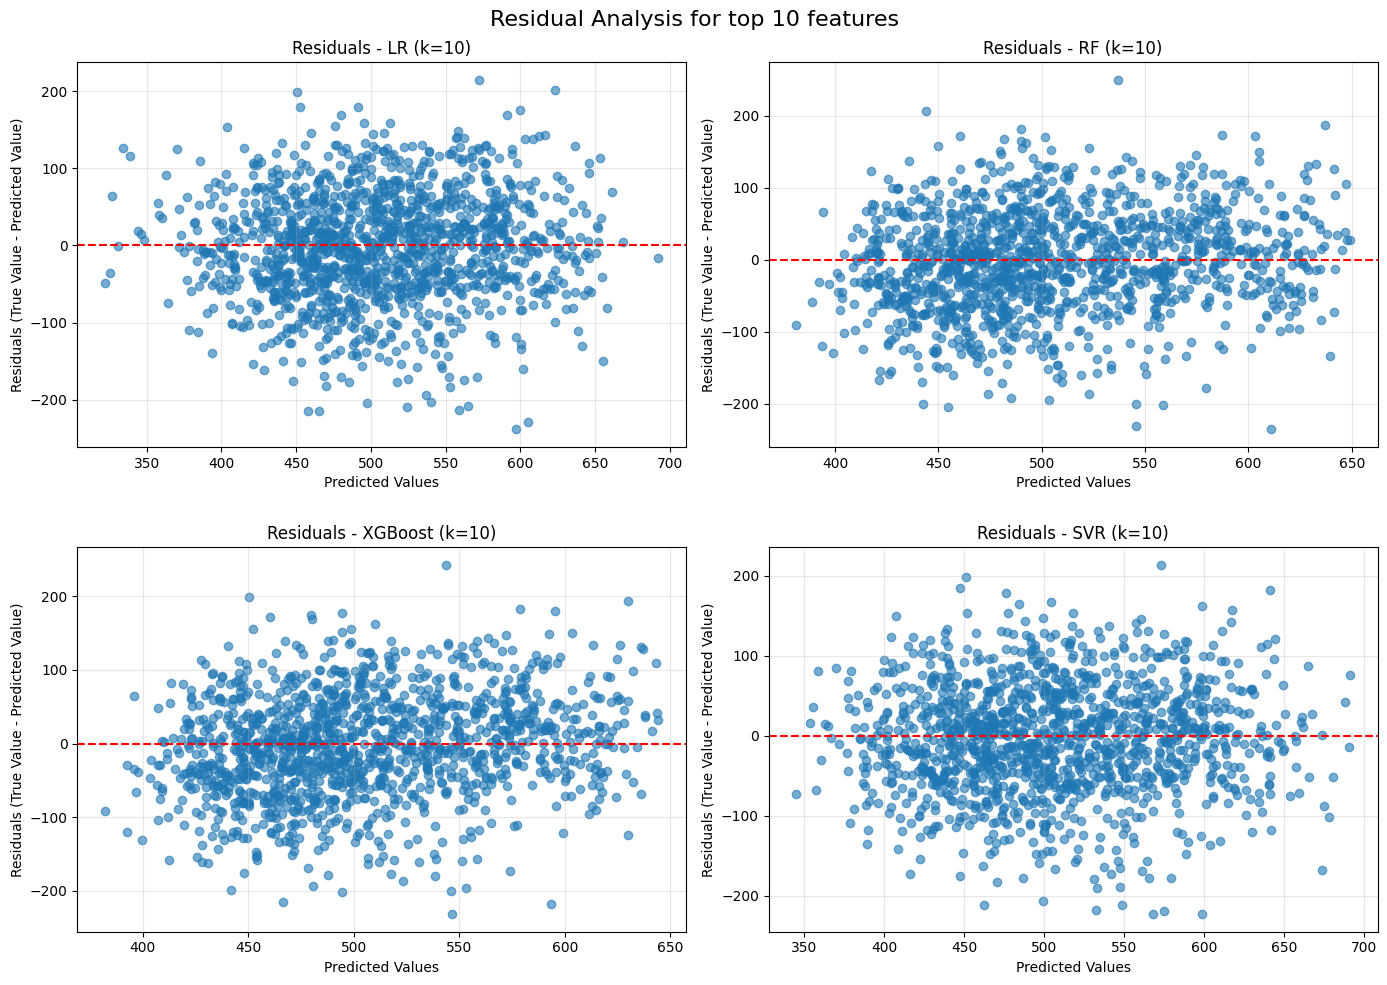

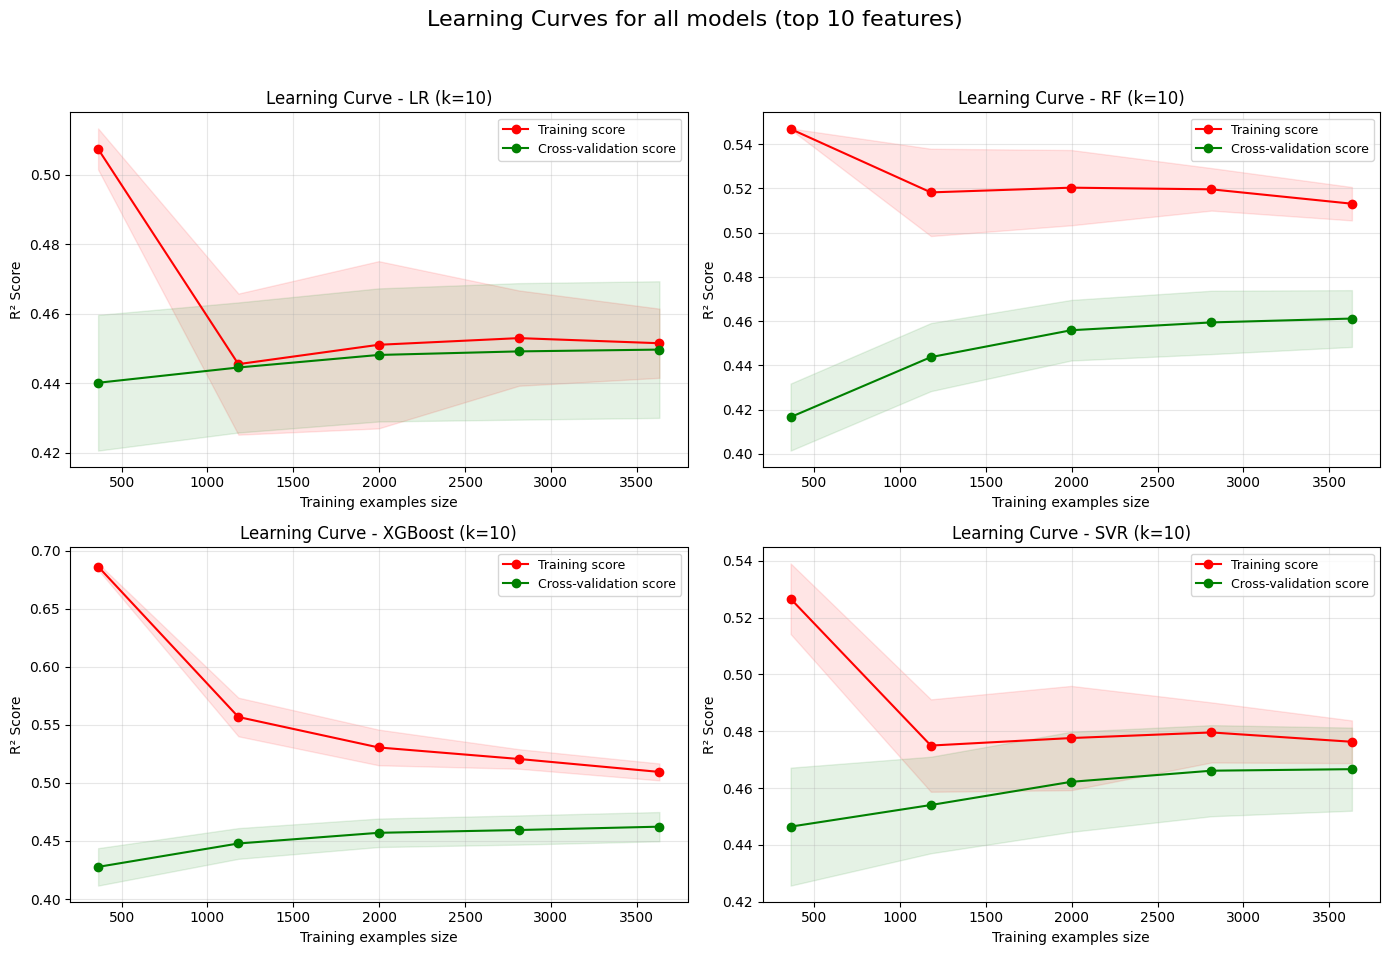

In [6]:

from src.model_training import evaluate_k_values
from src.tables import save_detailed_results_by_k, save_summary_of_metrics
from src.visualisations import (
    save_learning_curves_plot_all_models,
    save_multiple_metrics_vs_features_plot,
    save_residuals_plot_from_all_results
)

regression_results_df, regression_all_results_dic = evaluate_k_values(
    X_train_after_var_thresh_reg,
    y_train,
    X_test_after_var_thresh_reg,
    y_test,
    final_features_ranking=final_features_ranking_reg,
    feature_names=selected_columns_var_thresh_reg,
    model_names=['LR', 'RF', 'XGBoost', 'SVR'],
    task='regression',
    k_values=[5, 10, 15, 20]
)

k_chosen = 10

save_detailed_results_by_k(regression_all_results_dic, task='regression')
save_summary_of_metrics(regression_results_df, task='regression')
save_multiple_metrics_vs_features_plot(regression_results_df, task='regression')

save_residuals_plot_from_all_results(regression_all_results_dic, k_chosen=k_chosen)
save_learning_curves_plot_all_models(regression_all_results_dic, k_chosen=k_chosen, X_train_after_var_thresh=X_train_after_var_thresh_reg, y_train=y_train, task='regression')

# Display model training results, tables and plots
print_files(f"{TABLES_DIR}/regression_detailed_results_by_k.txt")
print_files(f"{TABLES_DIR}/regression_summary_of_metrics.txt")

display_visualisation(f"{PLOTS_DIR}/regression_metrics_vs_features_plot.png")
display_visualisation(f"{PLOTS_DIR}/residual_plots_for_{k_chosen}_features.png")
display_visualisation(f"{PLOTS_DIR}/regression_learning_curves_top_{k_chosen}_features.png")